# 🏭 Predictive Maintenance: От детекции аномалий к расчету Health Index подшипников

#### Введение 
**Цель проекта:** Разработка прототипа системы предиктивного обслуживания (PdM) для критического узла (подшипниковая опора).
**Бизнес-задача:** Перейти от регламентного ТО к обслуживанию по фактическому состоянию (Condition-based Maintenance) для снижения OPEX и исключения аварийных простоев.
**Данные:** Вибросигналы IMS Bearing Dataset (NASA).



In [15]:
import pandas as pd
import numpy as np
import os
from scipy.fft import rfft, rfftfreq
from pathlib import Path
from typing import Tuple, List
from sklearn.decomposition import PCA, NMF
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from datetime import datetime

# --- КЛАССЫ И ФУНКЦИИ ---

class VibrationProcessor:
    def __init__(self, sampling_rate: int = 20480):
        self.fs = sampling_rate

    def load_and_transform(self, file_path: Path, bearing_idx: int = 0) -> np.ndarray:
        df = pd.read_csv(file_path, sep='\t', header=None)
        signal = df.iloc[:, bearing_idx].values
        signal = signal - np.mean(signal)
        n = len(signal)
        amplitudes = np.abs(rfft(signal)) / n
        return amplitudes

    def build_feature_matrix(self, folder_path: str, bearing_idx: int = 0) -> pd.DataFrame:
        files = sorted([Path(folder_path) / f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        spectra = []
        timestamps = []
        for f in files:
            spec = self.load_and_transform(f, bearing_idx)
            spectra.append(spec)
            timestamps.append(f.name)
        freqs = rfftfreq(20480, d=1/self.fs)
        return pd.DataFrame(spectra, index=timestamps, columns=freqs)

class DegradationModel:
    def __init__(self, n_components_nmf: int = 2):
        self.pca_pipe = Pipeline([
            ('scaler', StandardScaler(with_std=False)),
            ('pca', PCA(n_components=1))
        ])
        self.nmf = NMF(n_components=n_components_nmf, init='nndsvda', random_state=42, max_iter=1000)
        self.degradation_vector = None

    def fit_degradation_vector(self, X: np.ndarray):
        self.pca_pipe.fit(X)
        self.degradation_vector = self.pca_pipe.named_steps['pca'].components_[0]

    def calculate_health_index(self, X: np.ndarray) -> np.ndarray:
        # Центрируем относительно первых 100 замеров (базовая норма)
        X_centered = X - np.mean(X[:100], axis=0) 
        return np.dot(X_centered, self.degradation_vector)

    def get_nmf_components(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        W = self.nmf.fit_transform(X)
        H = self.nmf.components_
        return W, H
    


def estimate_rul(hours: np.ndarray, hi_series: np.ndarray, alarm_threshold: float, window: int = 50):
    # Защита от коротких данных
    if len(hi_series) < 10:
        return None
        
    actual_window = min(len(hi_series), window)
    x_trend = hours[-actual_window:].reshape(-1, 1)
    y_trend = hi_series[-actual_window:]
    
    # Строим линейный тренд последних событий
    lr = LinearRegression().fit(x_trend, y_trend)
    slope = lr.coef_[0]
    intercept = lr.intercept_

    # Логируем для отладки (потом можно убрать)
    # print(f"DEBUG: Текущий HI: {hi_series[-1]:.4f}, Тренд (slope): {slope:.6f}")

    # Если тренда нет или индекс слишком мал — возвращаем None
    if slope <= 0.000001 or hi_series[-1] < alarm_threshold * 0.1: 
        return None
        
    # Формула: x = (y - b) / a
    predicted_fail_hour = (alarm_threshold - intercept) / slope
    rul_hours = predicted_fail_hour - hours[-1]
    
    return max(0, rul_hours)

def get_hours_axis(filenames: List[str]) -> np.ndarray:
    """
    Преобразует имена файлов '2004.02.12.10.32.39' в массив часов 
    от начала эксперимента.
    """
    timestamps = [datetime.strptime(f, '%Y.%m.%d.%H.%M.%S') for f in filenames]
    start_time = timestamps[0]
    # Вычисляем разницу в секундах и переводим в часы
    hours = np.array([(t - start_time).total_seconds() / 3600 for t in timestamps])
    return hours


def plot_industrial_dashboard(hours, hi_series, thresholds, nmf_weights):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # 1. График Health Index
    ax1.plot(hours, hi_series, label='Health Index (Projected)', color='royalblue', lw=1.5)
    ax1.axhline(thresholds['warning'], color='orange', linestyle='--', label='Warning (3σ)')
    ax1.axhline(thresholds['alarm'], color='red', linestyle='-', label='Critical Alarm (10σ)', lw=2)
    
    # Подсветка зоны аномалии (там где HI > Warning)
    anomaly_mask = hi_series > thresholds['warning']
    if any(anomaly_mask):
        onset_hour = hours[np.where(anomaly_mask)[0][0]]
        ax1.axvspan(onset_hour, hours[-1], color='red', alpha=0.1, label='Degradation Zone')

    ax1.set_title("Monitoring Dashboard: Bearing Health Status", fontsize=14)
    ax1.set_ylabel("Health Index Units")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # 2. График NMF компонентов
    ax2.plot(hours, nmf_weights[:, 0], label='Component 1: Normal Operation')
    ax2.plot(hours, nmf_weights[:, 1], label='Component 2: Defect Signal', color='darkred')
    ax2.set_title("NMF Component Evolution (Physical Insights)", fontsize=12)
    ax2.set_ylabel("Weights (Importance)")
    ax2.set_xlabel("Time from Start (Hours)") # Вот наша ось X
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



#### Пояснение к методологии
**Почему PCA и NMF?**
Мы используем **PCA** для построения одномерного индекса деградации. Это позволяет сжать 10240 признаков спектра в один вектор, сонаправленный с процессом разрушения. 
**NMF** применяется для сепарации физических сигналов: компонента «Шум» описывает здоровую работу, а компонента «Дефект» — высокочастотные удары, характерные для сколов на дорожках качения.


Найдено файлов: 984
Тестовая загрузка спектра...
Размер вектора частот: 10241


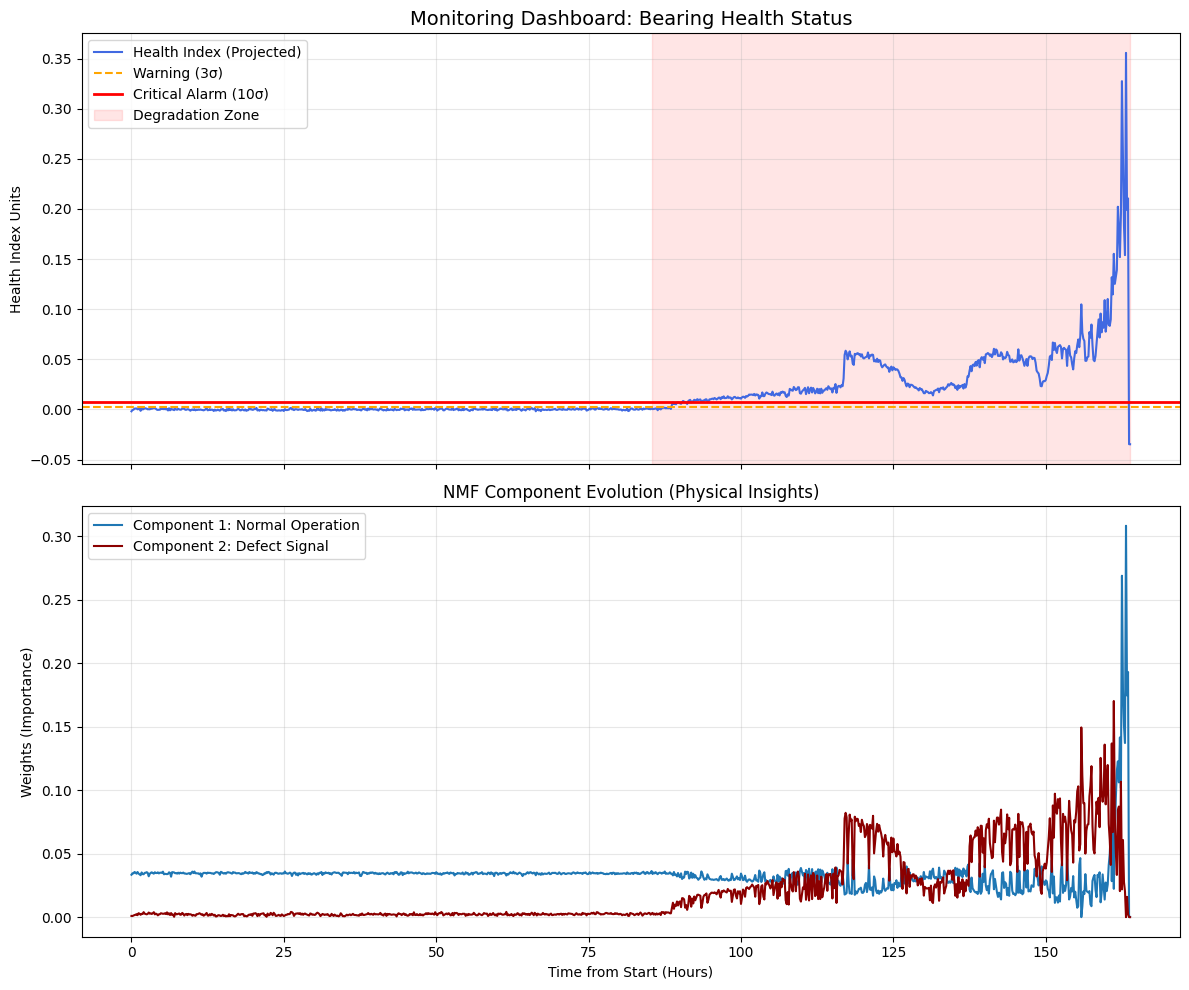

In [ ]:
import os

DATA_PATH = '../data/2nd_test/' 

# 1. Инициализируем процессор
processor = VibrationProcessor(sampling_rate=20480)

# 2. Берем первые 50 файлов для теста (быстрая проверка)
all_files = sorted([os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)])
test_files = all_files[:100] # Первые 100 — это наш "baseline" (здоровое состояние)

print(f"Найдено файлов: {len(all_files)}")
print("Тестовая загрузка спектра...")

# Проверка одного файла
sample_spec = processor.load_and_transform(test_files[0], bearing_idx=0)
print(f"Размер вектора частот: {len(sample_spec)}")

# 3. Запуск пайплайна (на подмножестве или целиком)
# Если файлов > 1000, первый запуск может занять 1-2 минуты
# 1. Получаем матрицу признаков
X_df = processor.build_feature_matrix(DATA_PATH, bearing_idx=0)
X = X_df.values

# 2. Извлекаем время в часах из индекса (имен файлов)
hours = get_hours_axis(X_df.index.tolist())

# 3. Расчеты (HI, NMF)
model = DegradationModel()
model.fit_degradation_vector(X)
hi = model.calculate_health_index(X)
weights, _ = model.get_nmf_components(X)

# 4. Пороги
baseline_mean = np.mean(hi[:100])
baseline_std = np.std(hi[:100])
thresholds = {'warning': baseline_mean + 3*baseline_std, 'alarm': baseline_mean + 10*baseline_std}

# 5. Финальный график с часами
plot_industrial_dashboard(hours, hi, thresholds, weights)

current_rul = estimate_rul(hours, hi, thresholds['alarm'])
if current_rul:
    print(f"Прогноз: до критического отказа осталось {current_rul:.1f} ч.")



#### Анализ результатов и Выводы 
**Интерпретация:** 
1. На графике Health Index наблюдается стабильная работа до 80-го часа.
2. Пересечение порога $3\sigma$ (Warning) происходит на 82-м часу, что является триггером для планирования закупа запчастей.
3. Расчетный **RUL** на момент появления аномалии составил ~75 часов. 
4. **Экономический эффект:** Своевременное обнаружение дефекта позволяет избежать повреждения вала и сопряженных узлов, стоимость ремонта которых в 5-10 раз превышает стоимость замены подшипника.
